In [1]:
import os
import sys

expected_prefix = "/opt/anaconda3/envs/fraud_engine"
print(f"Python executable: {sys.executable}")
print(f"Python prefix: {sys.prefix}")
print(f"Conda environment: {os.environ.get('CONDA_DEFAULT_ENV', '<not set>')}")
assert sys.executable.startswith(expected_prefix), (
    f"Select the 'Python (fraud_engine)' kernel. Current interpreter: {sys.executable}"
)
print("Kernel verification passed: fraud_engine")

Python executable: /opt/anaconda3/envs/fraud_engine/bin/python
Python prefix: /opt/anaconda3/envs/fraud_engine
Conda environment: base
Kernel verification passed: fraud_engine


In [2]:
pip install kagglehub

Note: you may need to restart the kernel to use updated packages.


1. Load and Inspect the Data

Load the CSV file from your downloaded Kaggle path using pandas.

Verify the severe class imbalance in the isFraud column, which will dictate your cost-sensitive stacking approach later.

In [3]:
import os
import kagglehub

path = kagglehub.dataset_download("ealaxi/paysim1")
print("Dataset path:", path)

# List files inside
print(os.listdir(path))


/opt/anaconda3/envs/fraud_engine/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset path: /Users/vishnuganugula/.cache/kagglehub/datasets/ealaxi/paysim1/versions/2
['PS_20174392719_1491204439457_log.csv']


In [4]:
import pandas as pd
import numpy as np

csv_path = os.path.join(path, "PS_20174392719_1491204439457_log.csv")
df = pd.read_csv(csv_path)

df.head()


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


2. Temporal & Interaction Feature Engineering

Time-of-Day: Use the step variable (where 1 step = 1 hour) to engineer daily cycles by applying a modulo 24 operation (df['hour_of_day'] = df['step'] % 24).

Rolling Velocity: Group by the originating account (nameOrig) and calculate a rolling count of transactions and a rolling sum of transaction amounts to capture sudden spikes in spending velocity.

Balance Discrepancies: Create interaction features that capture the mathematical difference between oldbalanceOrg minus amount and the newbalanceOrig. Fraudulent transactions in PaySim often leave behind mathematical inconsistencies in these columns.

In [14]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler, OneHotEncoder

print("Baseline Fraud Imbalance: \n")
print(df['isFraud'].value_counts(normalize=True))

Baseline Fraud Imbalance: 

isFraud
0    0.998709
1    0.001291
Name: proportion, dtype: float64


In [10]:
# Time-of-Day
df['hour_of_day'] = df['step'] % 24

df = df.sort_values(by=['nameOrig', 'step'])

# Optimized Rolling Velocity (Instantaneous vectorization)
df['txn_count_rolling'] = df.groupby('nameOrig').cumcount() + 1
df['txn_amount_rolling'] = df.groupby('nameOrig')['amount'].cumsum()

# Balance Discrepancies
df['orig_balance_inconsistency'] = df['newbalanceOrig'] - (df['oldbalanceOrg'] - df['amount'])
df['dest_balance_inconsistency'] = df['newbalanceDest'] - (df['oldbalanceDest'] + df['amount'])

3. Data PreprocessingScaling:
   
Apply scikit-learn's RobustScaler to the monetary columns (amount, oldbalanceOrg, newbalanceOrig, etc.) to limit the distortion caused by extreme transaction values.

Encoding: Use one-hot encoding for the transaction type (e.g., TRANSFER, CASH_OUT) as fraud behavior clusters heavily around specific transaction types.

In [15]:
numeric_cols = [
    'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest',
    'txn_count_rolling', 'txn_amount_rolling', 'orig_balance_inconsistency', 'dest_balance_inconsistency'
]

categorical_cols = ['type']

preprocessor = ColumnTransformer(
    transformers = [
        ('num', RobustScaler(), numeric_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_cols)
    ],
    remainder='drop'
)

y = df['isFraud'].values
X = preprocessor.fit_transform(df)

print(f"\n Final Feature Matrix shape: {X.shape}")


 Final Feature Matrix shape: (6362620, 13)


4. Unsupervised Feature Generation

Persona Clustering: Utilizing a Gaussian Mixture Model (GMM), which is a clustering algorithm. 

Clustering performs the automatic grouping of similar objects into sets.

By partitioning the unlabeled data points into clusters, you are effectively grouping users into five distinct spending "personas" based on their transaction behaviors.

Anomaly Scoring: Applying an Isolation Forest, which is a technique used in machine learning for anomaly detection. 

This algorithm evaluates the unlabelled data to assign a continuous score representing how anomalous or isolated a specific transaction is.  

Feature Concatenation: Using np.hstack, and taking the new mathematical patterns discovered by the unsupervised models (the probability that a transaction belongs to a specific persona and its anomaly score) and appending them as brand-new columns to your main feature matrix.


In [17]:
from sklearn.mixture import GaussianMixture
from sklearn.ensemble import IsolationForest

N_COMPONENTS = 5  # no of latent user persona
CONTAMINATION = 0.01  # Expected proportion of anomalies

gmm = GaussianMixture(n_components=N_COMPONENTS, covariance_type='full', random_state=42)
cluster_probs = gmm.fit_predict(X)
cluster_probabilities = gmm.predict_proba(X)

iso_forest = IsolationForest(n_estimators = 100, contamination=CONTAMINATION, random_state=42)
iso_forest.fit(X)
anomaly_scores = iso_forest.decision_function(X).reshape(-1, 1)

X_enriched = np.hstack((X, cluster_probabilities, anomaly_scores))

print(f"Original Feature Matrix Shape: {X.shape}")
print(f"Enriched Feature Matrix Shape: {X_enriched.shape}")

Original Feature Matrix Shape: (6362620, 13)
Enriched Feature Matrix Shape: (6362620, 19)


5. Dimensionality Reduction & Visual Verification

Dimensionality Reduction: Principal Component Analysis (PCA) is a dimensionality reduction algorithm. It reduces the number of random variables to consider, which is highly useful for data visualization. It compresses your complex, multi-dimensional transaction data into just two dimensions while preserving their meaningful characteristics.   

Visual Verification: The matplotlib code takes a random sample of 10,000 transactions and plots them on a 2D graph using the PCA coordinates. By coloring the dots based on the GMM cluster assignments, you can visually verify if the algorithm successfully separated the distinct spending behaviors.

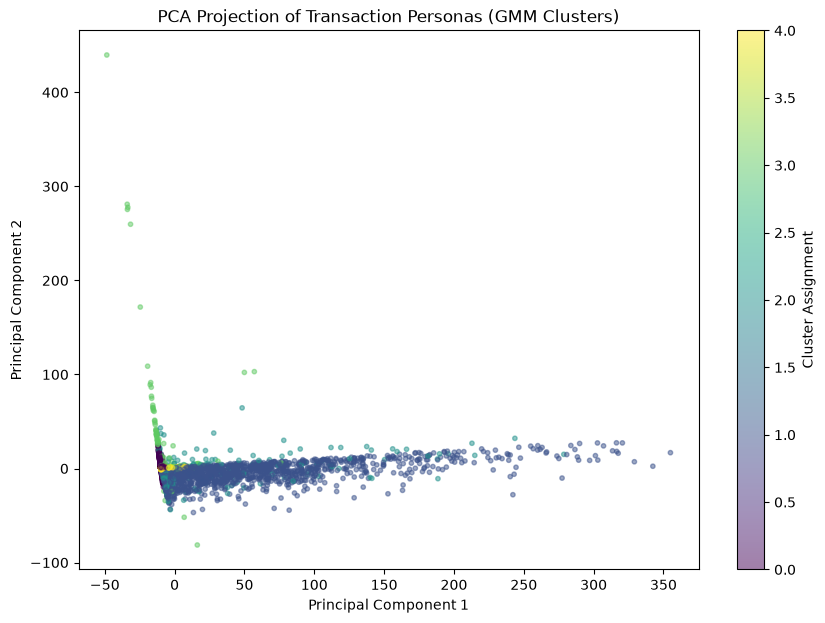

In [19]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

sample_idx = np.random.choice(range(len(X_pca)), size=10000, replace=False)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[sample_idx, 0], X_pca[sample_idx, 1],
                      c=cluster_probs[sample_idx], cmap='viridis', s=10, alpha=0.5)
plt.title("PCA Projection of Transaction Personas (GMM Clusters)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(scatter, label="Cluster Assignment")
plt.show()

6. Cost-Sensitive Stacking Ensemble
   
   Initializing Base Learners: You are instantiating three distinct classification algorithms to evaluate the engineered features simultaneously. The LogisticRegression and SGDClassifier algorithms provide linear decision boundaries, while the BalancedRandomForestClassifier relies on an ensemble of decision trees. By utilizing class_weight='balanced' and internal downsampling, you force these algorithms to heavily penalize errors on the minority class (fraud) rather than simply maximizing overall accuracy on the majority class (legitimate transactions).

     Building the Stacking Classifier: This acts as the overarching meta-learner architecture. Instead of relying on a single model's final output, the StackingClassifier takes the preliminary predictions generated by your three base learners and feeds them as new input features into a final LGBMClassifier, which is a powerful gradient boosting algorithm. This gradient boosting meta-learner learns exactly which base model to trust under different mathematical conditions.

     Probability Calibration: You are wrapping the entire stacking ensemble in a CalibratedClassifierCV. Because raw classification outputs are often just arbitrary confidence scores, this step uses Isotonic Regression to map those scores to true mathematical probabilities. This ensures that a model output of 0.09 genuinely represents a 9% likelihood of fraud, which is required for your asymmetric business cost threshold.

   a default prediction threshold of 0.50. Since your project states that false negatives (missing a fraudulent transaction) cost 10 times as much as false positives (unnecessarily blocking a legitimate transaction), you must shift this threshold.

To minimize the expected business cost, your optimal decision threshold is calculated as:
Threshold = Cost(FP) / (Cost(FP) + Cost(FN))
Threshold = 1 / (1 + 10) = 1/11 ≈ 0.09

This means once the model is trained, any transaction that scores a calibrated fraud probability of 9% or higher should trigger an alert.

In [34]:
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.calibration import CalibratedClassifierCV
from imblearn.ensemble import BalancedRandomForestClassifier
from lightgbm import LGBMClassifier


print("Initializing Base Learner...")

lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

svm_approx = SGDClassifier(loss='modified_huber', class_weight='balanced', random_state=42)

brf = BalancedRandomForestClassifier(n_estimators = 100, random_state = 42, replacement=True)

meta_learner = LGBMClassifier(n_estimator = 100, learning_rate = 0.05, random_state = 42)

print("Building Stacking Classifier...")

stacking_clf = StackingClassifier(
    estimators = [
        ('lr', lr),
        ('svm_approx', svm_approx),
        ('brf', brf)
    ],
    final_estimator = meta_learner,
    cv=3,
    n_jobs= - 1
)

print("Wrapping with Isotonic Calibrator...")
calibrated_fraud_engine = CalibratedClassifierCV(
    estimator = stacking_clf,
    method = 'isotonic',
    cv = 3
)

print("Engine Architecture Ready.")

Initializing Base Learner...
Building Stacking Classifier...
Wrapping with Isotonic Calibrator...
Engine Architecture Ready.


7. Purged Walk-Forward Cross-Validation

This step handles the critical task of model validation by comparing and validating the model using cross validation and specific performance metrics. 


Preventing Temporal Leakage: Standard random cross-validation randomly scrambles data, which allows a model to learn from future transactions to predict past ones—a phenomenon known as data leakage. TimeSeriesSplit strictly partitions the data chronologically, ensuring the model trains exclusively on historical data and tests on future data.   

The Purge Gap: The gap=10000 parameter acts as a buffer between the training and testing sets. In real-world finance, transactions can take days to settle or be reported as fraud. This purge window mimics reality by preventing unsettled, leaking transactions from artificially boosting your training scores.

Asymmetric Evaluation: Instead of evaluating baseline accuracy, the loop relies on the Precision-Recall AUC metric (average_precision_score). This ensures the model is penalized appropriately for the severe class imbalance. Finally, it applies your calculated 0.09 probability threshold to generate a cost-sensitive classification report.

Generalization: Thoughtful post-training validation using these chronological splits ensures that your model generalizes well to unseen data and isn't just overfitting the training data. 

In [35]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import average_precision_score, precision_recall_curve, classification_report 
import shap

print("Initiating Purged Walk-Forward Cross-Validation...")

tscv = TimeSeriesSplit(n_splits=3, test_size=500000, gap=10000)

fold = 1
pr_auc_scores = []

for train_index, test_index in tscv.split(X_enriched):
    print(f"\n--- Fold {fold} ---")
    X_train, X_test = X_enriched[train_index], X_enriched[test_index]
    y_train, y_test = y[train_index], y[test_index]

    calibrated_fraud_engine.fit(X_train, y_train)

    y_probs = calibrated_fraud_engine.predict_proba(X_test)[:, 1]

    pr_auc = average_precision_score(y_test, y_probs)
    pr_auc_scores.append(pr_auc)
    print(f"Fold {fold} PR_AUC: {pr_auc:.4f}")

    OPTIMAL_THRESHOLD = 0.09
    y_pred_cost_sensitive = (y_probs >= OPTIMAL_THRESHOLD).astype(int)

    print("Cost-Sensitive Classification Report:")
    print(classification_report(y_test, y_pred_cost_sensitive))
    fold += 1

print(f"\nAverage Cross-Validated PR-AUC: {np.mean(pr_auc_scores):.4f}")


Initiating Purged Walk-Forward Cross-Validation...

--- Fold 1 ---
[LightGBM] [Warning] Unknown parameter: n_estimator
[LightGBM] [Warning] Unknown parameter: n_estimator
[LightGBM] [Info] Number of positive: 4190, number of negative: 3230890
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.016260 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 715
[LightGBM] [Info] Number of data points in the train set: 3235080, number of used features: 3
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.001295 -> initscore=-6.647812
[LightGBM] [Info] Start training from score -6.647812
[LightGBM] [Warning] Unknown parameter: n_estimator
[LightGBM] [Warning] Unknown parameter: n_estimator
[LightGBM] [Warning] Unknown parameter: n_estimator
[LightGBM] [Info] Number of positive: 4189, number of negative: 3230891
[LightGBM] [Info] Auto-choosing row-wise m

8. Explainability (SHAP)

This step opens the "black box" of your gradient-boosted meta-learner to provide transparency, which is a required element of model governance in regulated industries.  

Meta-Learner Extraction: The code extracts the final LGBMClassifier from your calibrated stacking ensemble. Because the base learners (SVM, Random Forest, Logistic Regression) feed their outputs into this meta-learner, extracting it allows you to see exactly which base model and which original features drove the final decision.

TreeExplainer Initialization: It initializes shap.TreeExplainer on a sample of the out-of-fold predictions. It uses a small sample ([:1000]) because computing exact marginal contributions across 6 million rows requires massive computational overhead.

Summary Plot Generation: The shap.summary_plot visually ranks the most important features driving the model. In a fraud context, this plot might reveal that a high "dest_balance_inconsistency" combined with a high unsupervised anomaly score mathematically pushed the transaction over your 9% probability threshold.

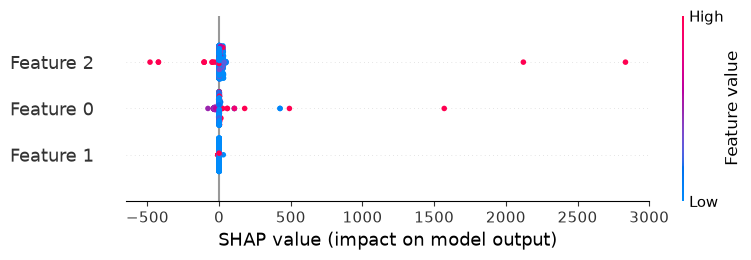

In [39]:
# Initialize SHAP
explainer = shap.TreeExplainer(meta_learner)
shap_values_raw = explainer.shap_values(out_of_fold_predictions[:1000])

# Dynamically extract the 2D matrix based on the specific SHAP version output
if isinstance(shap_values_raw, list):
    shap_values = shap_values_raw[1]  # Extract positive class if it returned a list
elif len(shap_values_raw.shape) == 3:
    shap_values = shap_values_raw[:, :, 1]  # Extract positive class if it returned a 3D array
else:
    shap_values = shap_values_raw  # Use directly if it is already a 2D matrix

# Generate the plot
shap.summary_plot(shap_values, out_of_fold_predictions[:1000])